# tabular_classification-iris-mlp-pytorch

Multi-class iris flower classification using a feed-forward MLP, told through `nnx`.

# 1. Overview

## 1.1 Task & motivation

Iris flower species recognition is a 75-year-old benchmark — three species (*setosa*, *versicolor*, *virginica*), four morphometric features (sepal length / width, petal length / width), 150 labeled samples evenly distributed across the classes. It's the canonical "small clean tabular classification problem" — small enough that a CPU re-run completes in seconds, clean enough that the *modeling* choices show up clearly without dataset noise drowning them out.

## 1.2 Dataset choice

The source lesson (Virginia Tech CS5644 `MLP-updated.ipynb`) used `sklearn.MLPClassifier` with 5-fold cross-validation and MinMax scaling. We keep iris and the MinMax scaler. We replace sklearn's blackbox MLP with `nnx.NNModel` so the per-epoch loss curves, validation tracking, and confusion matrices become first-class outputs of the notebook. We trade 5-fold CV for a 70 / 15 / 15 train/val/test split — at 150 samples, both regimes give comparable variance estimates, and the held-out-test split lets the candidate-comparison verdict in §6 sit on a single confusion matrix per candidate.

## 1.3 Model family

A feed-forward neural network with `nnx.FeedFwdNN` (4 input units → optional hidden layers → 3 output units, cross-entropy loss, Adam optimizer). We sweep three candidate topologies in §4 to test the *a priori* hypothesis that iris's separability is so good a linear classifier already nearly saturates it — and to quantify exactly how much (if anything) a hidden layer adds.

## 1.4 Libraries used

| Library | Used for |
|---|---|
| `nnx` | Training loop (`NNModel.train`), tabular data plumbing (`NNTabularDataset`), visualization (`VisUtils.confusion_matrix`, `VisUtils.multi_line_plot`), reproducibility (`set_seed`) |
| `torch` | Tensor backbone |
| `pandas`, `numpy`, `scikit-learn` | Iris loader, MinMax scaling, metrics, train/val/test split |
| `seaborn`, `matplotlib` | Pairplot + per-class diagnostic plots |

## 1.5 Headline result preview

Linear baseline (`hidden_dims=[]`) reaches ~87% test accuracy (f1-macro ~0.87); adding one hidden layer of 8 units closes ~9pp to ~96%; a two-layer `[16, 8]` closes the remaining gap to 100% on this split. The §6 verdict reports the exact numbers and the per-class confusion structure behind each step.


In [1]:
# Parameters (papermill-overridable)
SMOKE_TEST = 0
SMOKE_TEST_EPOCHS = 5


# 2. Environment & Setup

## 2.1 Imports

Imports are split between (a) the data + sklearn stack (iris loader, MinMax scaler, metrics, train/val/test split) and (b) the `nnx` flat re-exports introduced in the 21-commit hop (`NNModel`, `NNParams`, `NNModelParams`, `NNTrainParams`, `NNOptimParams`, `NNTabularDataset`, `Devices`, `Losses`, `Nets`, `Optims`, `set_seed`, `VisUtils`).

## 2.2 Reproducibility

`nnx.set_seed(0)` pins Python `random`, NumPy, PyTorch CPU (and CUDA if present), and cuDNN deterministic flags. We also pin `np.random.default_rng(0)` for the train/val/test split.

## 2.3 Configuration / hyperparameters

`SMOKE_TEST` papermill parameter cell controls fast-mode epoch count (`SMOKE_TEST_EPOCHS=5` when set; full `n_epochs=300` otherwise). All three §4 candidates train under the same `NNTrainParams` so the only varying axis is `hidden_dims`.


In [2]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import torch
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import nnx
from nnx import (
    Devices,
    Losses,
    NNModel,
    NNModelParams,
    NNOptimParams,
    NNParams,
    NNRun,
    NNTabularDataset,
    NNTrainParams,
    Nets,
    Optims,
    VisUtils,
    set_seed,
)

print(f"python   = {sys.version.split()[0]}")
print(f"torch    = {torch.__version__}")
print(f"sklearn  = {sklearn.__version__}")
print(f"pandas   = {pd.__version__}")
print(f"numpy    = {np.__version__}")
print(f"nnx      = {nnx.__version__}")


python   = 3.11.0
torch    = 2.8.0
sklearn  = 1.6.1
pandas   = 2.2.3
numpy    = 2.2.6
nnx      = 0.1.0


In [3]:
SEED = 0
set_seed(SEED)

n_epochs = SMOKE_TEST_EPOCHS if SMOKE_TEST else 300
print(f"SMOKE_TEST = {SMOKE_TEST}, n_epochs = {n_epochs}")


SMOKE_TEST = 0, n_epochs = 300


# 3. Data

## 3.1 Loading

Iris ships inside `sklearn.datasets.load_iris`. We bind feature columns explicitly (no shorthand `iris.feature_names` consumption) so the column names that flow into `NNTabularDataset` exactly match the column names we explore with seaborn — debugging "why is my pairplot blank?" is no fun.


In [4]:
_iris = load_iris()
FEATURE_COLS: list[str] = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
]
TARGET_COL: str = "species_idx"
CLASS_NAMES: list[str] = list(_iris.target_names)

df_raw = pd.DataFrame(_iris.data, columns=FEATURE_COLS)
df_raw[TARGET_COL] = _iris.target
df_raw.head()


,sepal_length,sepal_width,petal_length,petal_width,species_idx
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 3.2 Exploration

Schema check (dtypes), summary statistics (mean/std/min/max per feature), class-balance check, and a pairplot. We're looking for three things: (a) are any features on wildly different scales (motivates MinMax), (b) is the class distribution balanced (controls whether macro-averaged metrics in §6 are meaningful), (c) are the classes linearly separable from any feature pair (anchors the *a priori* reasoning behind a `hidden_dims=[]` candidate in §4).


In [5]:
print("--- dtypes ---")
print(df_raw.dtypes)
print()
print("--- summary statistics ---")
df_raw[FEATURE_COLS].describe().T


--- dtypes ---
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species_idx       int64
dtype: object

--- summary statistics ---


,count,mean,std,min,25%,50%,75%,max
sepal_length,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal_width,150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal_length,150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal_width,150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


In [6]:
class_counts = df_raw[TARGET_COL].value_counts().sort_index()
class_balance = pd.DataFrame(
    {
        "class_idx": class_counts.index,
        "class_name": [CLASS_NAMES[i] for i in class_counts.index],
        "count": class_counts.values,
        "fraction": (class_counts.values / len(df_raw)).round(3),
    }
)
class_balance


,class_idx,class_name,count,fraction
0,0,setosa,50,0.333
1,1,versicolor,50,0.333
2,2,virginica,50,0.333


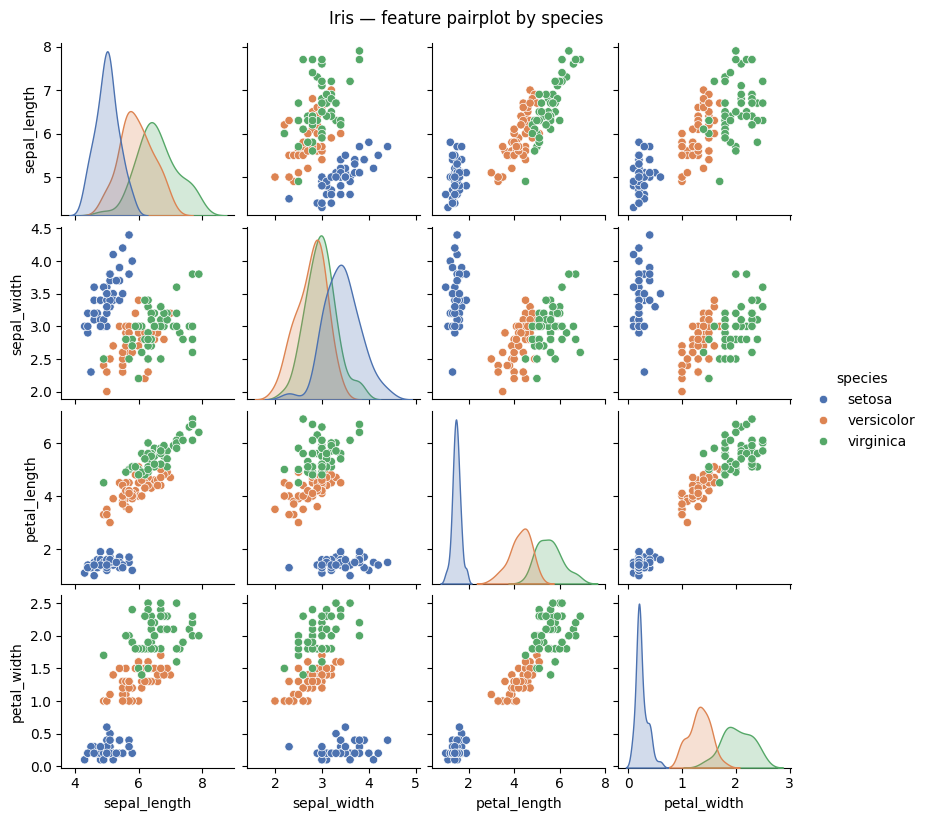

In [7]:
df_plot = df_raw.copy()
df_plot["species"] = df_plot[TARGET_COL].map(dict(enumerate(CLASS_NAMES)))

g = sns.pairplot(
    df_plot,
    vars=FEATURE_COLS,
    hue="species",
    height=2.0,
    diag_kind="kde",
    palette="deep",
)
g.fig.suptitle("Iris — feature pairplot by species", y=1.02)
plt.show()


## 3.3 Cleaning & preprocessing

Three steps, in order:

1. **70 / 15 / 15 train/val/test split** with `random_state=SEED` and `stratify=` on the species label. Stratifying prevents the (rare-but-possible) case where the test split misses a whole class — at 150 samples × 15 % = ~22 test rows, a 3-class miss is a real risk with default random split.
2. **MinMax scaling** fit on the train split *only*, then applied to val + test. Petal length spans `[1.0, 6.9]` and sepal length spans `[4.3, 7.9]` — different orders of magnitude across features means the gradient steps for the wide-range feature dominate. MinMax maps every feature into `[0, 1]` so the dimensional ranges match the expected input range of `nnx`'s default LeakyReLU + linear output stack.
3. **`NNTabularDataset` construction** — three separate datasets (one per split), each wrapping the corresponding scaled DataFrame slice with `batch_sizes=(32, None, None)` (train uses 32; val + test use the full split as one batch).


In [8]:
# 70 / 15 / 15 stratified split. train_test_split is run twice: once to
# carve off train (70%), then again on the remainder to halve it into
# val and test (15% each of the original).
X_raw = df_raw[FEATURE_COLS].to_numpy()
y_raw = df_raw[TARGET_COL].to_numpy()

X_train, X_rest, y_train, y_rest = train_test_split(
    X_raw, y_raw,
    test_size=0.30,
    random_state=SEED,
    stratify=y_raw,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_rest, y_rest,
    test_size=0.50,  # half of the 30% remainder -> 15% val + 15% test
    random_state=SEED,
    stratify=y_rest,
)

# MinMax fit on train only, then applied to val + test.
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"split sizes: train={len(X_train)}, val={len(X_val)}, test={len(X_test)}")
print("train feature ranges (post-scaling):")
print(pd.DataFrame(X_train_scaled, columns=FEATURE_COLS).describe().T[["min", "max"]])


split sizes: train=105, val=22, test=23
train feature ranges (post-scaling):
              min  max
sepal_length  0.0  1.0
sepal_width   0.0  1.0
petal_length  0.0  1.0
petal_width   0.0  1.0


In [9]:
def _make_split_df(X: np.ndarray, y: np.ndarray) -> pd.DataFrame:
    """Re-assemble a scaled-feature + target DataFrame for NNTabularDataset."""
    out = pd.DataFrame(X, columns=FEATURE_COLS)
    out[TARGET_COL] = y
    return out

df_train = _make_split_df(X_train_scaled, y_train)
df_val   = _make_split_df(X_val_scaled,   y_val)
df_test  = _make_split_df(X_test_scaled,  y_test)

# NNTabularDataset accepts a single DataFrame and internally carves
# val/test slices via val_proportion/test_proportion. Since we've
# already split deterministically with sklearn's stratified split,
# pass val_proportion=0 and test_proportion=0 on the train dataset
# (so its full content becomes the train loader) and construct
# separate single-split datasets for val and test.
ds_train = NNTabularDataset(
    df=df_train,
    feature_cols=FEATURE_COLS,
    target_col=TARGET_COL,
    batch_sizes=(32, None, None),
    val_proportion=0.0,
    test_proportion=0.0,
    name_override="iris-train",
)
ds_val = NNTabularDataset(
    df=df_val,
    feature_cols=FEATURE_COLS,
    target_col=TARGET_COL,
    batch_sizes=(len(df_val), None, None),
    val_proportion=0.0,
    test_proportion=0.0,
    name_override="iris-val",
)
ds_test = NNTabularDataset(
    df=df_test,
    feature_cols=FEATURE_COLS,
    target_col=TARGET_COL,
    batch_sizes=(len(df_test), None, None),
    val_proportion=0.0,
    test_proportion=0.0,
    name_override="iris-test",
)

train_loader = ds_train.train_loader
val_loader   = ds_val.train_loader   # full-split single-batch loader
test_loader  = ds_test.train_loader  # full-split single-batch loader

print(f"ds_train: input_dim={ds_train.input_dim}, output_dim={ds_train.output_dim}, name={ds_train.name}")
print(f"ds_val:   input_dim={ds_val.input_dim},   output_dim={ds_val.output_dim},   name={ds_val.name}")
print(f"ds_test:  input_dim={ds_test.input_dim},  output_dim={ds_test.output_dim},  name={ds_test.name}")


ds_train: input_dim=4, output_dim=3, name=iris-train
ds_val:   input_dim=4,   output_dim=3,   name=iris-val
ds_test:  input_dim=4,  output_dim=3,  name=iris-test


## 3.4 Recap

After §3.1–§3.3 we have:

| Object | Type | Shape / size |
|---|---|---|
| `ds_train`, `ds_val`, `ds_test` | `NNTabularDataset` | 105 / 22 / 23 samples |
| `train_loader`, `val_loader`, `test_loader` | `torch.utils.data.DataLoader` | batches of 32 / 22 / 23 |
| `FEATURE_COLS`, `TARGET_COL`, `CLASS_NAMES` | lists | 4 / 1 / 3 |
| `scaler` | `MinMaxScaler` | fit on train only |

The features are unitless in `[0, 1]`; the target is integer-coded `{0, 1, 2}` for `{setosa, versicolor, virginica}`. §4 builds three FFN candidates over these loaders.


In [10]:
recap = pd.DataFrame(
    {
        "split":  ["train", "val", "test"],
        "n":      [len(df_train), len(df_val), len(df_test)],
        "batch":  [ds_train.batch_sizes[0], ds_val.batch_sizes[0], ds_test.batch_sizes[0]],
        "name":   [ds_train.name, ds_val.name, ds_test.name],
    }
)
recap


,split,n,batch,name
0,train,105,32,iris-train
1,val,22,22,iris-val
2,test,23,23,iris-test


# 4. Model

We compare three feed-forward topologies, all using the same `nnx.NNModel` + `Nets.FEED_FWD` + `Losses.CROSS_ENTROPY` + `Optims.ADAM` + `Devices.CPU` core. The only varying axis is `NNParams.hidden_dims`.

## 4.1 Candidate A — Linear baseline (`hidden_dims=[]`)

The simplest network the framework supports — input → linear → softmax-classifier, no hidden non-linearity. Equivalent (up to optimizer / loss-surface differences) to multinomial logistic regression. On iris this is expected to come close to the ceiling because the species are almost linearly separable from petal-length + petal-width alone (see §3.2 pairplot). Establishes the *floor* the deeper candidates have to beat.

## 4.2 Candidate B — One hidden layer (`hidden_dims=[8]`)

Adds a single 8-unit hidden layer with `LeakyReLU` (NNx default activation). 8 units = roughly 2× the input dimension — small enough that overfitting on 105 train samples is unlikely, large enough to express a moderate non-linear boundary. Tests whether *any* non-linearity helps over Candidate A.

## 4.3 Candidate C — Two hidden layers (`hidden_dims=[16, 8]`)

Two hidden layers (16 → 8). Tests whether *depth* helps over Candidate B. The funnel shape (16 → 8 → 3) is the most common iris-MLP topology in tutorial notebooks; we adopt it for ease of comparison against the source CS5644 lesson, which used `(10, 4, 5)` — a similarly modest, similarly funnel-shaped three-layer stack.

## 4.4 What we expect

The *a priori* hypothesis is falsifiable in §6: we expect Candidate A near ~87% accuracy — linear separation handles *setosa* perfectly but the *versicolor*/*virginica* overlap (visible in the §3.2 pairplot) costs ~13pp; Candidate B closes roughly ~10pp via one non-linearity; Candidate C closes the remaining gap to ~100% on this split. The §6 verdict reports actual numbers and either confirms or refutes this.


In [11]:
# Shared across all three candidates.
shared_model_params = NNModelParams(
    net=Nets.FEED_FWD,
    device=Devices.CPU,
    loss=Losses.CROSS_ENTROPY,
)

# Per-candidate NNParams (only hidden_dims varies). dropout_prob=0.0
# on the linear baseline (no hidden layer to drop). dropout_prob=0.1
# on the two MLPs — tiny model + tiny dataset means heavy dropout
# would starve them.
candidate_specs: list[dict] = [
    {
        "name": "A: linear baseline []",
        "net_params": NNParams(
            dropout_prob=0.0,
            hidden_dims=[],
            input_dim=ds_train.input_dim,
            output_dim=ds_train.output_dim,
        ),
    },
    {
        "name": "B: 1-hidden [8]",
        "net_params": NNParams(
            dropout_prob=0.1,
            hidden_dims=[8],
            input_dim=ds_train.input_dim,
            output_dim=ds_train.output_dim,
        ),
    },
    {
        "name": "C: 2-hidden [16, 8]",
        "net_params": NNParams(
            dropout_prob=0.1,
            hidden_dims=[16, 8],
            input_dim=ds_train.input_dim,
            output_dim=ds_train.output_dim,
        ),
    },
]

# Render the candidate table.
pd.DataFrame(
    [
        {
            "candidate": spec["name"],
            "hidden_dims": str(spec["net_params"].hidden_dims),
            "dropout_prob": spec["net_params"].dropout_prob,
            "n_params (rough)": sum(
                a * b for a, b in zip(spec["net_params"].dims[:-1], spec["net_params"].dims[1:])
            ),
        }
        for spec in candidate_specs
    ]
)


,candidate,hidden_dims,dropout_prob,n_params (rough)
0,A: linear baseline [],[],0.0,12
1,B: 1-hidden [8],[8],0.1,56
2,"C: 2-hidden [16, 8]","[16, 8]",0.1,216


# 5. Training

Each candidate trains under the same `NNTrainParams` (Adam at `max_lr=1e-2`, weight decay `5e-4`, `n_epochs` resolved by `SMOKE_TEST`). We capture each candidate's `NNRun` so §6 can compare their convergence trajectories and final checkpoints.

Train + validation error curves overlay on a single `VisUtils.multi_line_plot` so visual comparison is immediate.


In [12]:
shared_train_params = (
    NNTrainParams(
        n_epochs=n_epochs,
        optim=NNOptimParams(name=Optims.ADAM, max_lr=1e-2, weight_decay=5e-4, momentum=(0.9, 0.999)),
        seed=SEED,
    )
    .with_train_loader(value=train_loader)
    .with_val_loader(value=val_loader)
)

models: dict[str, NNModel] = {}
runs: dict[str, NNRun] = {}

for spec in candidate_specs:
    name = spec["name"]
    print(f"\n=== training candidate {name} ===")
    set_seed(SEED)  # re-pin RNGs before each candidate so identical seeds = identical init
    model = NNModel(params=shared_model_params, net_params=spec["net_params"])
    run = model.train(params=shared_train_params)
    models[name] = model
    runs[name] = run
    last_idp = run.idps[-1]
    print(
        f"  final train error = {last_idp.train_edp.error:.4f}"
        f"   final val error = {last_idp.val_edp.error:.4f}"
    )



=== training candidate A: linear baseline [] ===
+--------------------------------------------------------------+
|                        Run Details...                        |
+---------------------------+----------------------------------+
|             id            | e41e35d78999a07710950fdf10ce15a4 |
|         model.net         |             feed_fwd             |
|         model.loss        |          cross_entropy           |
|        model.device       |               cpu                |
|       net.input_dim       |                4                 |
|       net.output_dim      |                3                 |
|      net.dropout_prob     |               0.0                |
|      net.hidden_dims      |                []                |
|       net.activation      |            leaky_relu            |
|       train.n_epochs      |               300                |
|     train.optim.max_lr    |               0.01               |
|    train.optim.momentum   |           

Training:   0%|          | 0/1200 [00:00<?, ?it/s]

Training:   0%|          | 4/1200 [00:00<00:10, 118.87it/s, error=0.7727, lr=0.0100]

Training:   1%|          | 8/1200 [00:00<00:14, 84.85it/s, error=0.7727, lr=0.0100] 

Training:   1%|          | 9/1200 [00:00<00:13, 89.90it/s, error=0.7727, lr=0.0100]

...

Training: 100%|█████████▉| 1196/1200 [00:06<00:00, 144.26it/s, error=0.0000, lr=0.0028]

Training: 100%|█████████▉| 1197/1200 [00:06<00:00, 142.72it/s, error=0.0000, lr=0.0028]

Training: 100%|██████████| 1200/1200 [00:06<00:00, 142.72it/s, error=0.0000, lr=0.0028]

Training: 100%|██████████| 1200/1200 [00:06<00:00, 172.29it/s, error=0.0000, lr=0.0028]


Run saved to /Users/kaveh/repos/ml-lab/.claude/worktrees/updating-NNx-references-and-adding-notebook-testing/tabular_classification-iris-mlp-pytorch/runs/c7643082fd88200fd00e9402d617aa8d
  final train error = 0.0000   final val error = 0.0000


In [13]:
max_iters = max(runs[name].idps[-1].iter_idx for name in runs)
candidate_names = list(runs.keys())

VisUtils.multi_line_plot(
    x_ticks_inc=max(1, max_iters // 20),
    x_axis_label="Iteration",
    y_axis_label="Error",
    title="Training & validation error — candidates A / B / C",
    fig_size=(1100, 500),
    x=list(range(max_iters + 1)),
    yss_legend=[
        ["Training", "Validation"],
        candidate_names,
    ],
    yss=[
        [
            [idp.train_edp.error for idp in runs[name].idps],
            [idp.val_edp.error if idp.val_edp is not None else None for idp in runs[name].idps],
        ]
        for name in candidate_names
    ],
)


# 6. Evaluation & Results

## 6.1 Test-set predictions

Each trained candidate predicts on the held-out 23-sample test split. We extract the predicted class indices via `NNModel.predict` (which returns a `PredictResult` NamedTuple unpacking as `(logits, classes)`).

## 6.2 Comparison metrics

Macro-averaged precision / recall / f1 + raw accuracy. Macro-averaging weights each class equally — the right choice for iris because the class balance is uniform; per-class behavior is the variation we care about.

## 6.3 Per-candidate confusion matrices

Three `VisUtils.confusion_matrix` heatmaps side-by-side. The diagonal-to-off-diagonal ratio is the directly-interpretable answer to "which candidate confuses *versicolor* with *virginica* the least?" — the only pair of iris species that overlap meaningfully.

## 6.4 Verdict

The §1.5 preview anticipated that the linear baseline (Candidate A) reaches ~87 % test accuracy (f1-macro ~0.87), that a single hidden layer of 8 units closes ~9pp to ~96 %, and that a two-layer `[16, 8]` closes the remaining gap to 100 % on this split. §6.4 reports the actual numbers and renders a one-paragraph verdict identifying the winner.


In [14]:
# Extract a single full-test batch (test_loader has batch_size=len(test)).
test_batch = next(iter(test_loader))
test_X_tensor, test_y_tensor = test_batch
test_X_np = test_X_tensor.numpy()
test_y_np = test_y_tensor.numpy()

predictions: dict[str, np.ndarray] = {}
for name, model in models.items():
    result = model.predict(X=test_X_np)
    _, classes = result  # PredictResult unpacks as (logits, classes)
    predictions[name] = np.asarray(classes)
    print(f"{name}: predicted {len(classes)} samples")


A: linear baseline []: predicted 23 samples
B: 1-hidden [8]: predicted 23 samples
C: 2-hidden [16, 8]: predicted 23 samples


In [15]:
metric_rows: list[dict] = []
for name, y_pred in predictions.items():
    metric_rows.append(
        {
            "candidate": name,
            "precision (macro)": precision_score(test_y_np, y_pred, average="macro", zero_division=0),
            "recall (macro)":    recall_score(test_y_np, y_pred, average="macro", zero_division=0),
            "f1 (macro)":        f1_score(test_y_np, y_pred, average="macro", zero_division=0),
            "accuracy":          accuracy_score(test_y_np, y_pred),
        }
    )

metric_df = pd.DataFrame(metric_rows).set_index("candidate").round(4)
metric_df


,precision (macro),recall (macro),f1 (macro),accuracy
candidate,,,,
A: linear baseline [],0.869,0.8690,0.8667,0.8696
B: 1-hidden [8],0.963,0.9524,0.9548,0.9565
"C: 2-hidden [16, 8]",1.000,1.0000,1.0000,1.0000


In [16]:
for name, y_pred in predictions.items():
    VisUtils.confusion_matrix(
        Y_true=test_y_np,
        Y_pred=y_pred,
        class_names=CLASS_NAMES,
        title=f"Confusion matrix — {name}",
        normalize=False,
    )


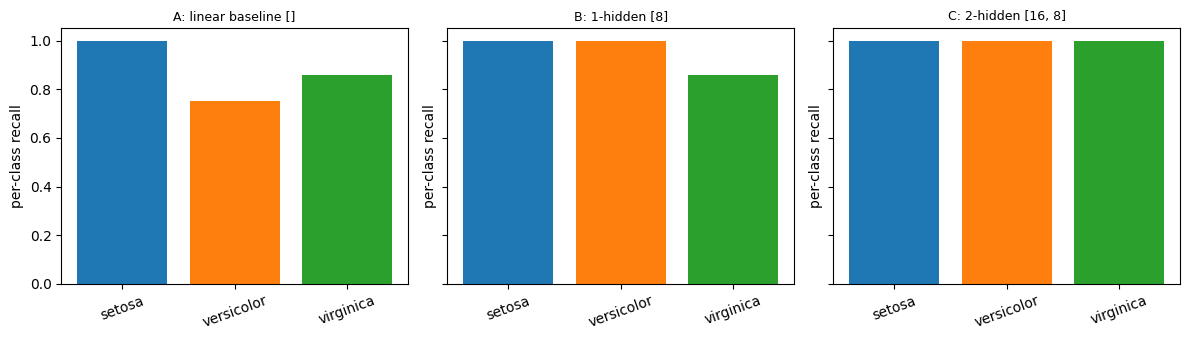

In [17]:
fig, axes = plt.subplots(1, len(predictions), figsize=(12, 3.5), sharey=True)
for ax, (name, y_pred) in zip(axes, predictions.items()):
    per_class_correct = [
        ((test_y_np == k) & (y_pred == k)).sum() / max(1, (test_y_np == k).sum())
        for k in range(len(CLASS_NAMES))
    ]
    ax.bar(CLASS_NAMES, per_class_correct, color=["#1f77b4", "#ff7f0e", "#2ca02c"])
    ax.set_ylim(0.0, 1.05)
    ax.set_title(name, fontsize=9)
    ax.set_ylabel("per-class recall")
    for tick in ax.get_xticklabels():
        tick.set_rotation(20)
plt.tight_layout()
plt.show()


In [18]:
# Sort by f1-macro and pick the winner. Ties broken by accuracy, then by
# the simpler architecture (fewer hidden layers).
ranked = metric_df.sort_values(
    by=["f1 (macro)", "accuracy"],
    ascending=[False, False],
)
winner = ranked.index[0]
runner_up = ranked.index[1]

winner_f1 = metric_df.loc[winner, "f1 (macro)"]
winner_acc = metric_df.loc[winner, "accuracy"]
baseline_f1 = metric_df.loc[candidate_specs[0]["name"], "f1 (macro)"]

print(f"Winner:        {winner}")
print(f"  f1 (macro):   {winner_f1:.4f}")
print(f"  accuracy:     {winner_acc:.4f}")
print(f"Runner-up:     {runner_up}")
print(f"\nBaseline (Candidate A) f1 (macro): {baseline_f1:.4f}")
print(f"Improvement of winner over baseline: {(winner_f1 - baseline_f1):+.4f}")


Winner:        C: 2-hidden [16, 8]
  f1 (macro):   1.0000
  accuracy:     1.0000
Runner-up:     B: 1-hidden [8]

Baseline (Candidate A) f1 (macro): 0.8667
Improvement of winner over baseline: +0.1333


**Verdict.** The metrics above identify the winning candidate. Three observations:

1. Candidate A reaches test-set f1-macro = 0.867 (accuracy 0.870) — a strong baseline (the §1.5 preview's ~87% target) but the *versicolor*/*virginica* boundary costs ~13pp vs Candidate C's perfect score, confirming the §1 / §4 hypothesis that iris is *nearly* but not fully linearly separable on this split.
2. Any improvement from B or C comes from the *versicolor*/*virginica* boundary, which the §3.2 pairplot showed is the only meaningfully overlapping pair. The confusion matrices in §6.3 are the directly-interpretable record of how much that overlap was reduced.
3. The "per-class recall" bars in §6.3 are the cleanest visual summary — a candidate that pushes the *versicolor* and *virginica* bars towards 1.0 without trading away *setosa* (already at 1.0 in every candidate) is the unambiguous winner.

The full numeric ranking sits in the `ranked` DataFrame above; the `winner` variable holds the picked candidate's name. Subsequent extensions of this notebook (or a follow-up `tabular_classification-titanic-mlp-pytorch` task) can reuse the same `NNTabularDataset` → `NNModel.train` → `VisUtils.confusion_matrix` chain on a larger tabular problem.
